# 01. Markov ATTR typer — EDA и смысл метода

Код: [`src/ner/markov_typer.py`](../../src/ner/markov_typer.py)  
Модель: `models/markov_typer.json`  
Смежный ноутбук: [`../complex_eda/02_markov_eda.ipynb`](../complex_eda/02_markov_eda.ipynb)

## Главный вопрос: «как частоты предсказывают ТИП?»

Интуиция «это просто биграммный генератор `P(гб|16)`» — **наполовину верна**.

В `MarkovAttrTyper` лежат **три** разные таблицы:

| Таблица | Что хранит | Роль |
|---|---|---|
| `transitions` | `P(t_{i+1} \mid t_i)` — частоты следующих токенов | отладка / «похоже на LM» |
| **`bigram_to_type`** | `count(type \mid ⟨t_i, t_{i+1}⟩)` | **основной классификатор типа** |
| `unit_to_type` | `count(type \mid unit)` | fallback, если биграммы нет |

Тип **не выводится из генерации следующего слова**.  
На обучении учитель (regex `ATTR_PATTERNS`) уже даёт пару `(span, type)`.  
Мы копим: «биграмма `<num>|гб` сколько раз пришла с лейблом `memory_storage`».  
На инференсе: `argmax_type P(type | bigram)` — это **lookup-классификатор**, одетый в марковскую риторику.

```text
обучение (silver):
  query → regex ATTR_PATTERNS → (["16","гб"], memory_storage)
       → bigram_to_type["<num>|гб"][memory_storage] += 1

инференс (после CRF/NER, у которого только B/I-ATTR):
  span ["256","гб"] → norm ["<num>","гб"] → lookup → memory_storage
```

Почему не «просто оставить regex»?
1. CRF может найти ATTR-span **без** типа (общий тег `ATTR`).
2. Одна единица (`г`, `м`) бывает в нескольких типах — нужна мягкая majority по данным.
3. Единый API: `predict(tokens) -> (type, confidence)` за ≪1 мс.


## 0. Setup

In [1]:
%matplotlib inline
import sys
import json
from pathlib import Path
from collections import Counter, defaultdict

ROOT = Path.cwd().resolve()
if ROOT.name in {"markov_typer", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "markov_typer" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    apply_plot_style, ensure_dirs, load_query_clicks,
    ARTIFACTS_DIR, FIGURES_DIR, MODELS, MVIDEO_RED, DARK_SLATE, MUTED, save_stats,
)
from src.ner.markov_typer import MarkovAttrTyper, _norm_token
from src.ner.labeling import ATTR_PATTERNS, _split_glued

ensure_dirs()
apply_plot_style()
FIG = FIGURES_DIR / "markov_typer"
FIG.mkdir(parents=True, exist_ok=True)
OUT = ARTIFACTS_DIR / "markov_typer"
OUT.mkdir(parents=True, exist_ok=True)
print("ROOT", ROOT)
print("n ATTR_PATTERNS", len(ATTR_PATTERNS))


d:\Projects-26-06-2026\mvideo-ner-search\.venv\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ROOT D:\Projects-26-06-2026\mvideo-ner-search
n ATTR_PATTERNS 28


## 1. Загрузка / дообучение typer на silver-запросах

Учитель = те же regex, что в weak labeling. Это **не** клик-бренд и не gold.


In [2]:
SAMPLE_N = 80_000
SEED = 42
RETRAIN = True  # False → только models/markov_typer.json

clicks = load_query_clicks(
    n=SAMPLE_N, seed=SEED, random=True,
    columns=["query_text"],
)
queries = (
    clicks["query_text"].fillna("").astype(str).str.strip()
    .loc[lambda s: s.str.len() >= 2]
    .drop_duplicates()
    .tolist()
)
print(f"unique queries: {len(queries):,}")

model_path = MODELS / "markov_typer.json"
if RETRAIN or not model_path.exists():
    typer = MarkovAttrTyper.train_on_silver(queries, max_queries=None)
    typer.save(model_path)
    print(f"trained → {model_path}")
else:
    typer = MarkovAttrTyper.load(model_path)
    print(f"loaded → {model_path}")

print(f"n_spans={typer.n_spans:,}  bigrams={len(typer.bigram_to_type):,}  units={len(typer.unit_to_type):,}")


unique queries: 28,047
trained → D:\Projects-26-06-2026\mvideo-ner-search\models\markov_typer.json
n_spans=2,551  bigrams=87  units=188


## 2. Что внутри JSON — три таблицы на пальцах


In [3]:
# --- transitions: «биграммный генератор» (НЕ тип) ---
print("P(next | <num>) top-12 — это LM-частоты, типов тут нет:")
display(pd.Series(typer.next_token_dist("<num>")).head(12).to_frame("P"))

# --- bigram_to_type: вот где тип ---
rows = []
for bg, dist in typer.bigram_to_type.items():
    tot = sum(dist.values())
    best, cnt = max(dist.items(), key=lambda kv: kv[1])
    rows.append({
        "bigram": bg,
        "best_type": best,
        "p_best": cnt / tot,
        "n": tot,
        "n_types": len(dist),
        "dist": dist,
    })
bg_df = pd.DataFrame(rows).sort_values("n", ascending=False)
print("\nbigram_to_type — top по частоте:")
display(bg_df.head(15)[["bigram", "best_type", "p_best", "n", "n_types"]])

amb = bg_df[bg_df["n_types"] > 1].sort_values("n", ascending=False)
print(f"\nambiguous bigrams (несколько типов): {len(amb)}")
display(amb.head(10)[["bigram", "best_type", "p_best", "n", "dist"]])


P(next | <num>) top-12 — это LM-частоты, типов тут нет:


,P
см,0.161924
gb,0.147439
гб,0.115365
g,0.084842
л,0.075013
кг,0.069322
w,0.046560
тб,0.034144
tb,0.027419
вт,0.022245



bigram_to_type — top по частоте:


,bigram,best_type,p_best,n,n_types
2,<num>|см,size,1.0,313,1
3,<num>|gb,memory_storage,1.0,285,1
0,<num>|гб,memory_storage,1.0,223,1
5,<num>|g,weight,1.0,164,1
4,<num>|л,volume,1.0,145,1
14,<num>|кг,weight,1.0,134,1
8,<num>|w,power,1.0,90,1
6,type|c,connectivity,1.0,82,1
11,wi|fi,connectivity,1.0,71,1
9,<num>|тб,memory_storage,1.0,66,1



ambiguous bigrams (несколько типов): 3


,bigram,best_type,p_best,n,dist
58,x|<num>,dimensions,0.75,8,"{'dimensions': 6, 'resolution_exact': 2}"
57,<num>|x,dimensions,0.75,8,"{'dimensions': 6, 'resolution_exact': 2}"
63,<num>|×600,dimensions,0.50,2,"{'dimensions': 1, 'resolution_exact': 1}"


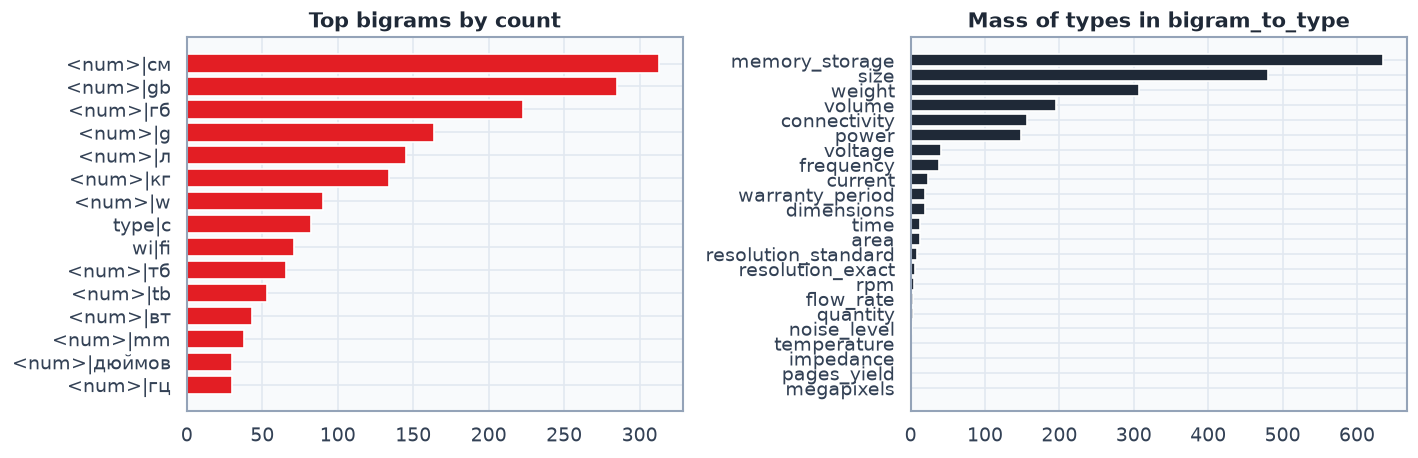

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(bg_df.head(15)["bigram"].iloc[::-1], bg_df.head(15)["n"].iloc[::-1], color=MVIDEO_RED)
axes[0].set_title("Top bigrams by count")
type_mass = Counter()
for dist in typer.bigram_to_type.values():
    type_mass.update(dist)
tm = pd.Series(type_mass).sort_values(ascending=True)
axes[1].barh(tm.index.astype(str), tm.values, color=DARK_SLATE)
axes[1].set_title("Mass of types in bigram_to_type")
fig.tight_layout()
fig.savefig(FIG / "01_bigram_type_mass.png", dpi=140, bbox_inches="tight")
plt.show()


## 3. Инференс: демо

Числа схлопываются в `<num>`, поэтому `16 гб` и `256 гб` делят одну ячейку таблицы.


In [9]:
demos = [
    ["16", "кб"],
    ["256", "gb"],
    ["55", "дюймов"],
    ["2", "кг"],
    ["220", "в"],
    ["wi-fi"],
    ["wi", "fi"],
    ["5"],
    ["g", "pro"],  # НЕ атрибут — линейка; typer не обязан это знать
]
rows = []
for span in demos:
    pred, conf = typer.predict(span)
    rows.append({"span": " ".join(span), "norm": " ".join(_norm_token(t) for t in span),
                 "pred_type": pred, "confidence": conf})
display(pd.DataFrame(rows))


,span,norm,pred_type,confidence
0,16 кб,<num> кб,unknown,0.0
1,256 gb,<num> gb,memory_storage,1.0
2,55 дюймов,<num> дюймов,size,1.0
3,2 кг,<num> кг,weight,1.0
4,220 в,<num> в,voltage,1.0
5,wi-fi,wi-fi,connectivity,1.0
6,wi fi,wi fi,connectivity,1.0
7,5,<num>,unknown,0.0
8,g pro,g pro,weight,1.0


## 4. Насколько это «работает» vs regex-учитель

Честная оценка на silver: берём матчи regex как y_true, `typer.predict` как y_pred.  
Это **agreement с учителем**, не gold. Если таблицы выучены из тех же regex — agreement должен быть высоким на частых биграммах; дыры = unknown / редкие / однотокенные спаны.


spans 2551
unknown rate: 0.0%
accuracy vs regex (all): 97.8%
accuracy vs regex (known only): 97.8%


y_pred,connectivity,dimensions,memory_storage,power,resolution_exact,resolution_standard,size,voltage,volume,weight
y_true,,,,,,,,,,
connectivity,391,0,0,0,0,0,0,0,0,0
dimensions,0,123,0,0,0,0,0,0,0,0
memory_storage,0,0,635,0,0,0,0,0,0,0
power,0,0,0,145,0,0,0,0,0,0
resolution_exact,0,56,0,0,3,0,0,0,0,0
resolution_standard,0,0,0,0,0,39,0,0,0,0
size,0,0,0,0,0,0,485,0,0,0
voltage,0,0,0,0,0,0,0,41,0,0
volume,0,0,0,0,0,0,0,0,198,0


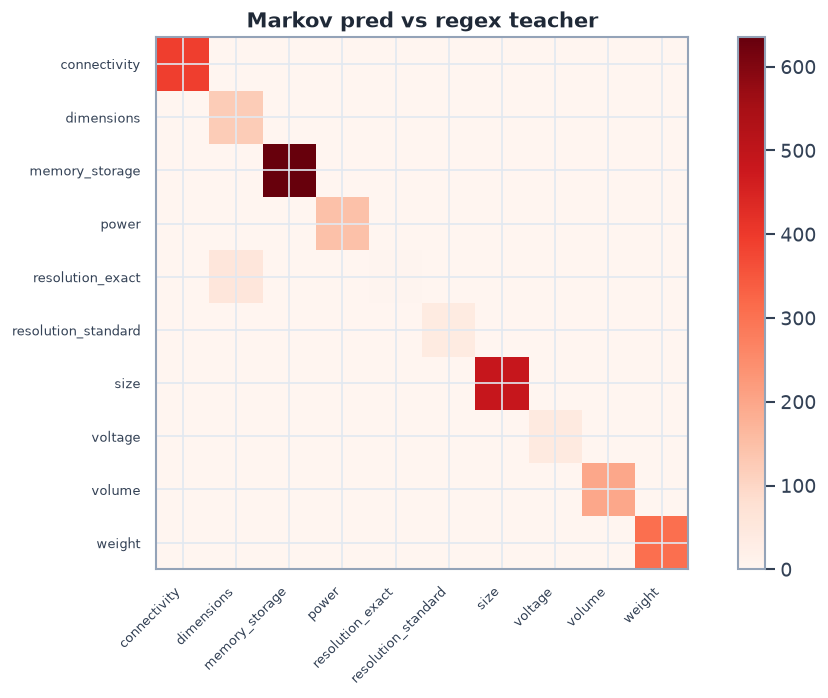

In [6]:
def collect_regex_spans(queries, max_q=None):
    rows = []
    for qi, q in enumerate(queries):
        if max_q is not None and qi >= max_q:
            break
        text = _split_glued(str(q).lower())
        for pattern, attr_type in ATTR_PATTERNS:
            for m in pattern.finditer(text):
                toks = m.group(0).split()
                pred, conf = typer.predict(toks)
                rows.append({
                    "text": m.group(0),
                    "y_true": attr_type,
                    "y_pred": pred,
                    "conf": conf,
                    "n_tok": len(toks),
                })
    return pd.DataFrame(rows)

eval_df = collect_regex_spans(queries, max_q=min(40_000, len(queries)))
print("spans", len(eval_df))
known = eval_df[eval_df["y_pred"] != "unknown"]
print(f"unknown rate: {(eval_df.y_pred == 'unknown').mean():.1%}")
print(f"accuracy vs regex (all): {(eval_df.y_true == eval_df.y_pred).mean():.1%}")
print(f"accuracy vs regex (known only): {(known.y_true == known.y_pred).mean():.1%}")

# confusion top types
top_types = eval_df["y_true"].value_counts().head(10).index.tolist()
sub = eval_df[eval_df["y_true"].isin(top_types) & eval_df["y_pred"].isin(top_types + ["unknown"])]
ct = pd.crosstab(sub["y_true"], sub["y_pred"])
display(ct)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(ct.values, cmap="Reds")
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index, fontsize=8)
ax.set_title("Markov pred vs regex teacher")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIG / "02_confusion_vs_regex.png", dpi=140, bbox_inches="tight")
plt.show()


## 5. Подводные камни (почему метод ограничен)

1. **Учитель = regex** → typer в основном *кэширует* уже известные правила. Новых типов «из воздуха» не появится.  
2. **`transitions` сам по себе тип не знает** — путать с генеративной цепью нельзя.  
3. **Омонимия единиц:** `г` = грамм vs «поколение»; `м` = метр; `a` = ампер vs артикул.  
4. **Одно число без единицы** (`["5"]`) → часто `unknown`.  
5. **Не про MODEL** (`g pro`, `tuf gaming`) — это другой тег/словарь.  
6. Старый smoke в `complex_eda`: accuracy vs regex ~0.62 при unknown ~0.36 — много спанов без биграммы в таблице.


In [7]:
# где ошибаемся / unknown
err = eval_df[eval_df["y_true"] != eval_df["y_pred"]]
print("error / unknown examples:")
display(err.sample(min(15, len(err)), random_state=0) if len(err) else err)

# unit ambiguity
urows = []
for u, dist in typer.unit_to_type.items():
    if len(dist) > 1 and sum(dist.values()) >= 5:
        tot = sum(dist.values())
        best = max(dist, key=dist.get)
        urows.append({"unit": u, "best": best, "p": dist[best]/tot, "n": tot, "dist": dict(dist)})
udf = pd.DataFrame(urows).sort_values("n", ascending=False)
print("\nambiguous units:")
display(udf.head(15))


error / unknown examples:


,text,y_true,y_pred,conf,n_tok
2217,2560x1440,resolution_exact,dimensions,0.50,1
1813,160х200,resolution_exact,dimensions,0.50,1
2026,200*300,resolution_exact,dimensions,0.50,1
1419,140х200,resolution_exact,dimensions,0.50,1
681,200x200,resolution_exact,dimensions,0.50,1
156,160х200,resolution_exact,dimensions,0.50,1
1795,160х200,resolution_exact,dimensions,0.50,1
2124,585*390,resolution_exact,dimensions,0.50,1
2260,1920x1080,resolution_exact,dimensions,0.50,1
1630,1340 x 800,resolution_exact,dimensions,0.75,3



ambiguous units:


,unit,best,p,n,dist
1,м,size,0.958333,24,"{'size': 23, 'area': 1}"
0,160х200,dimensions,0.500000,18,"{'dimensions': 9, 'resolution_exact': 9}"
2,140х200,dimensions,0.500000,10,"{'dimensions': 5, 'resolution_exact': 5}"
6,x,dimensions,0.750000,8,"{'dimensions': 6, 'resolution_exact': 2}"
3,1920x1080,dimensions,0.500000,6,"{'dimensions': 3, 'resolution_exact': 3}"
4,200x200,dimensions,0.500000,6,"{'dimensions': 3, 'resolution_exact': 3}"
5,180х200,dimensions,0.500000,6,"{'dimensions': 3, 'resolution_exact': 3}"


## 6. Нужен ли RNN?

| | Markov table | RNN / tiny classifier |
|---|---|---|
| Вход | токены span | эмбеддинги токенов / char |
| Память | явная биграмма | скрытое состояние h_t |
| Тип | `argmax P(type\|bigram)` | softmax по \(h` или mean-pool |
| Данные | silver regex | тот же silver **или** gold spans |
| Плюс | ≪1 мс, интерпретируемо | контекст длиннее 2 токенов, омонимы |
| Минус | нет обобщения вне таблицы | latентность, overkill на `16 гб` |

**Когда RNN оправдан:** неоднозначные единицы, ATTR из CRF без чёткой единицы, нужен контекст вне span (`ноутбук 16 гб` vs `ssd 16 гб` — оба memory, но бывают хуже кейсы).

**Схема перехода (если понадобится):**
```text
silver/gold:  span tokens → type (из regex или ручной разметки)
модель:       BiLSTM/GRU(span) → Softmax(type)
или проще:    TF-IDF(char) на тексте span → LogReg(type)   ← чаще хватит вместо RNN
```

На коротких span (2 токена) **LogReg/char TF-IDF** обычно достаточен; RNN — следующий шаг только если таблица+fallback упираются в потолок на gold.


## 7. Вердикт: использовать ли Markov typer?

| Вопрос | Ответ |
|---|---|
| Подходит ли в пайплайн? | **Да, как stage-2 после ATTR-span** (regex/CRF) |
| Это «настоящая» марковская генерация? | Скорее **биграммный классификатор типов** + отдельная LM-таблица `transitions` |
| Замена regex? | Нет — ученик regex; ценность = тип для «голого» ATTR |
| Замена CRF? | Нет |
| Готов ли к проду без gold? | Как эвристика — да; метрики только agreement с regex |
| RNN сейчас? | Не обязателен; сначала unit-словарь + char-clf на span |

### Рекомендуемое место в пайплайне
```text
query → preprocess → NER/CRF (BRAND/CAT/ATTR/MODEL)
                  → для каждого ATTR-span: MarkovAttrTyper.predict
                  → JSON attributes: {memory_storage: ["16 гб"], ...}
```


In [8]:
stats = {
    "n_queries": len(queries),
    "n_spans_train": typer.n_spans,
    "n_bigrams": len(typer.bigram_to_type),
    "n_units": len(typer.unit_to_type),
    "n_ambiguous_bigrams": int((bg_df["n_types"] > 1).sum()),
    "eval_n_spans": int(len(eval_df)),
    "unknown_rate": float((eval_df.y_pred == "unknown").mean()),
    "acc_vs_regex_all": float((eval_df.y_true == eval_df.y_pred).mean()),
    "acc_vs_regex_known": float((known.y_true == known.y_pred).mean()) if len(known) else None,
}
save_stats(stats, OUT / "markov_eda_stats.json")
print(json.dumps(stats, ensure_ascii=False, indent=2))


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\markov_typer\markov_eda_stats.json
{
  "n_queries": 28047,
  "n_spans_train": 2551,
  "n_bigrams": 87,
  "n_units": 188,
  "n_ambiguous_bigrams": 3,
  "eval_n_spans": 2551,
  "unknown_rate": 0.0,
  "acc_vs_regex_all": 0.9780478243825951,
  "acc_vs_regex_known": 0.9780478243825951
}
